In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from copy import deepcopy
import jax
import jax.numpy as jnp

# Euclid software
from cloelite.cosmology.jax_cosmology import JAXBackground
from cloelite.cosmology.jax_cosmology import JAXLinearPerturbations
from cloelite.cosmology.jax_cosmology import JAXNonLinearPerturbations
from cloelite.observables.two_point import AngularTwoPoint
from cloelite.observables import photo
import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

## Reading n(z)

In [2]:
# Read the dndz
z_pos, dndz_pos = el.photo.redshift_distributions('../data/nz.pos.fits')
z_she, dndz_she = el.photo.redshift_distributions('../data/nz.wl.fits')

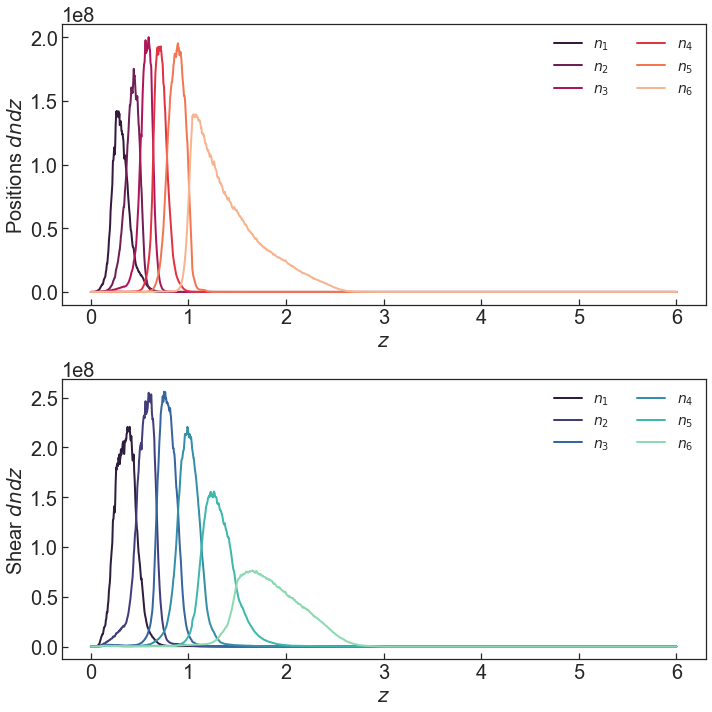

In [3]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in dndz_pos.keys():
    axs[0].plot(z_pos, dndz_pos[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in dndz_she.keys():
    axs[1].plot(z_she, dndz_she[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $dndz$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $dndz$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

In [4]:
# Normalise dndz
dndz_pos_norm = deepcopy(dndz_pos)
for key in dndz_pos.keys():
    dndz_pos_norm[key] = dndz_pos[key] / integrate.trapezoid(
                        dndz_pos[key], z_pos)

dndz_she_norm = deepcopy(dndz_she)
for key in dndz_she.keys():
    dndz_she_norm[key] = dndz_she[key] / integrate.trapezoid(
                        dndz_she[key], z_she)


# Resampling the normalized n(z) with 300 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
myz = np.linspace(1e-3, 3., 300)
my_dndz_pos_norm = np.zeros([len(dndz_pos.keys()), 300])
for i in range(6):
    my_dndz_pos_norm[i,:] = np.interp(myz, z_pos, my_dndz_pos[i,:])

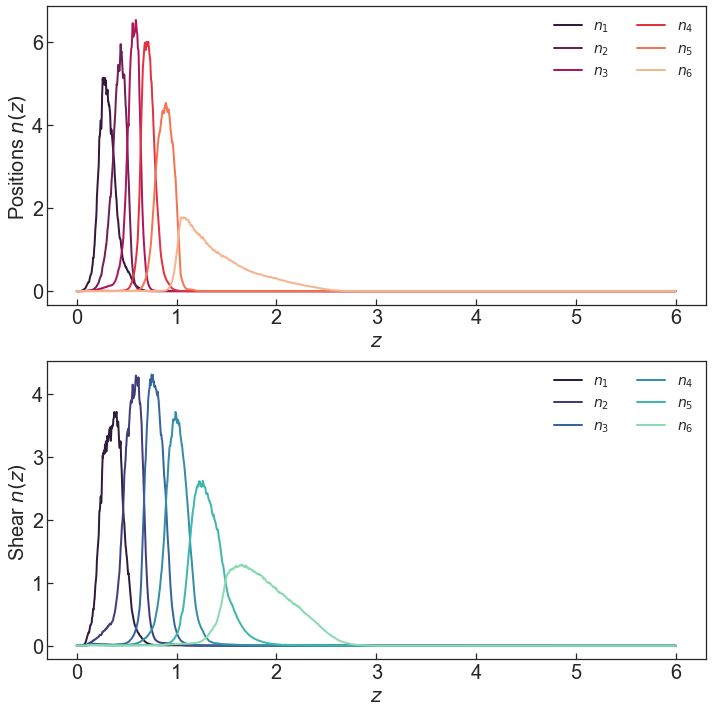

In [5]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in dndz_pos.keys():
    axs[0].plot(z_pos, dndz_pos_norm[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in dndz_she.keys():
    axs[1].plot(z_she, dndz_she_norm[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

## Cosmology: background and perturbations

In [6]:
# Initialize Background cosmology
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
Omm = 0.3097
Omc = 0.26067408193677466
Omb = 0.04902591806322532
w = -1.0
wa = 0.
cloeparams = np.array([h, Omc, Omb, sigma8, w, wa])
#background = JAXBackground(H0=H0,Omc=Omc,Omb=Omb, w=w, wa=wa, As = 3, sigma8=sigma8, Omk = 0.0, ns = 0.96, gamma_MG = 0.545)
background = JAXBackground(67.74, 0.0486, 0.2589, 0.0, 2e-9, 0.9667, -1.0, 0.0, 0.8159, 0.55)

In [7]:
print(cloeparams)

[ 0.677       0.26067408  0.04902592  0.8277     -1.          0.        ]


In [8]:
JAXBackground?

Init signature:
JAXBackground(
    H0: float,
    Omb: float,
    Omc: float,
    Omk: float,
    As: float,
    ns: float,
    w: float,
    wa: float,
    sigma8: float,
    gamma_MG: float,
)
Docstring:     
Helper class that provides a standard way to create an ABC using
inheritance.
Init docstring:
A class to define background cosmology using JAX
and inheriting from Cosmology parent class
File:           ~/CosmoProjects/differentiablestuff/cloelite/cloelite/cosmology/jax_cosmology.py
Type:           ABCMeta
Subclasses:     


In [9]:
# Initialize Linear and NonLinearPerturbations
linear_pert = JAXLinearPerturbations(background)
nonlinear_pert = JAXNonLinearPerturbations(linear_pert)

In [10]:
jnp.ndim(4)

0

In [11]:
jnp.atleast_1d(5).shape

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


(1,)

In [12]:
jnp.array([4.]).shape

(1,)

In [13]:
ks = jnp.logspace(-5,1,300)
plt.loglog(ks, nonlinear_pert.nonlinear_matter_power_spectrum(ks, jnp.array([4.])), '--', label = 'nonlinear, z=4')
plt.loglog(ks, nonlinear_pert.nonlinear_matter_power_spectrum(ks, jnp.array([0.])), '--', label = 'nonlinear, z=0')

#plt.loglog(ks, linear_pert.linear_matter_power_spectrum(ks,4.), label = 'linear, z=4')
#plt.loglog(ks, linear_pert.linear_matter_power_spectrum(ks,0.), label = 'linear, z=0')

plt.ylabel(r'$P_{\rm \delta \delta}(k)$')
plt.xlabel('$k$')
plt.legend(loc=3, fontsize = 14);

TypeError: Only integer scalar arrays can be converted to a scalar index.

## Observables: tracers & 2-point statistics

In [ ]:
# Define the tracers

tracer_she = photo.ShearTracer(nonlinear_pert,
                            dndz=my_dndz_pos_norm,
                            z = myz,
                            intrinsic_aligment_model='zNLA',
                            nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41})

tracer_pos = photo.PositionsTracer(nonlinear_pert,
                            dndz=my_dndz_pos_norm,
                            z = myz,
                            magnification_bias_model = 'linear',
                            galaxy_bias_model= 'linear',
                            nuisance_params={'param1': 1.0})

In [ ]:
# # Plot the dndz
# i = 0
# j = 0
# fig, axs = plt.subplots(4, 1, figsize=(15,15))
# for ax in axs.flatten():
#     ax.tick_params(axis='both',which='both',direction='in')
# for i in dndz_pos.keys():
#     axs[0].plot(myz, tracer_pos.get_window_positions(myz)[i-1], label = '$n_{{{}}}$'.format(i), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i-1])
# for i in dndz_she.keys():
#     axs[1].plot(myz, tracer_she.get_lensing_window(myz)[i-1], label = '$n_{{{}}}$'.format(i), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[i-1])
# for i in dndz_she.keys():
#     axs[2].plot(myz, tracer_she.get_window_IA(myz)[i-1], label = '$n_{{{}}}$'.format(i), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[i-1])
#     j=j+1
# for i in dndz_she.keys():
#     axs[3].plot(myz, tracer_she.get_window(myz)[i-1], label = '$n_{{{}}}$'.format(i), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[i-1])
#     j=j+1

# axs[0].set_xlabel(r'$z$')
# axs[0].set_ylabel(r'$W^D_i(z)$')
# axs[1].set_ylabel(r'$W^\gamma_i(z)$')
# axs[2].set_ylabel(r'$W^{\rm IA}_i(z)$')
# axs[3].set_ylabel(r'$W^{\rm WL}_i(z)$')
# axs[0].legend(frameon=False, ncol=2, loc = 1);
# axs[1].legend(frameon=False, ncol=2, loc = 1);
# axs[2].legend(frameon=False, ncol=2, loc = 1);
# axs[3].legend(frameon=False, ncol=2, loc = 1);
# plt.tight_layout()

In [ ]:
# Define angular two point
#Cl_GG = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl() # pass ell?
#Cl_GL = AngularTwoPoint(tracer_pos, tracer_she).get_Cl() 
Cl_LL = AngularTwoPoint(tracer_she, tracer_she).get_Cl()

In [ ]:
Nbins = len(list(dndz_she.keys()))
Nbins

In [ ]:
def extract_upper_triangular(arra):
    indices = jnp.triu_indices(Nbins)
    upt = arra[:, indices[0], indices[1]]
    clsflat = upt.T
    return clsflat

In [ ]:
# Define ell range
ell_range = np.logspace(1., np.log10(3000), 100)

In [ ]:
# for i in dndz_pos.keys():
#     plt.loglog(ell_range, ell_range*(2*ell_range+1)*Cl_GG[:,i-1,i-1], label = '$n_{{{}}}$'.format(i), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i-1])
# plt.xlabel(r'$z$')
# plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$');
# plt.legend(fontsize=14);

In [ ]:
# for i in dndz_she.keys():
#     plt.loglog(ell_range, ell_range*ell_range*Cl_LL[:,i-1,i-1], label = '$n_{{{}}}$'.format(i), linewidth=2, color=sns.color_palette("mako", len(dndz_she.keys()))[i-1])
# plt.xlabel(r'$z$')
# plt.ylabel(r'$\ell (2\ell +1)C^{\rm EE}(\ell)$');
# plt.legend(fontsize=14);

In [ ]:
# for i in dndz_she.keys():
#     plt.loglog(ell_range, ell_range*(2*ell_range)*Cl_LL[:,i-1,i-1], label = '$n_{{{}}}$'.format(i), linewidth=2, color=sns.color_palette("mako", len(dndz_she.keys()))[i-1])
# plt.xlabel(r'$z$')
# plt.ylabel(r'$\ell (2\ell +1)C^{\rm Eg}(\ell)$');
# plt.legend(fontsize=14);

In [ ]:
@jax.jit
def cloelite_mean(params):
    cosmoparams = params
    background = JAXBackground(cosmoparams[0], cosmoparams[2], cosmoparams[1], 
                               0.0, 2.1265e-9, 0.9667, cosmoparams[4], cosmoparams[5], cosmoparams[3], 0.55)
    linear_pert = JAXLinearPerturbations(background)
    nonlinear_pert = JAXNonLinearPerturbations(linear_pert)
    tracer_she = photo.ShearTracer(nonlinear_pert,
                            dndz=my_dndz_pos_norm,
                            z = myz,
                            intrinsic_aligment_model='zNLA',
                            nuisance_params={'AIA': 0, 'CIA': 0.0134, 'EtaIA':0.})
    Cl_LL = AngularTwoPoint(tracer_she, tracer_she).get_Cl()
    clsflat = extract_upper_triangular(Cl_LL)
    return clsflat.flatten()
    

In [ ]:
cloe_3x2_mu = cloelite_mean(cloeparams)

In [ ]:
import numpy as onp

In [ ]:
onp.ndim(Cl_GG)

In [ ]:
jnp.ndim(Cl_GG)

In [ ]:
import jax_cosmo as jc

In [ ]:
cosmojc = jc.Planck15(h=h, sigma8=sigma8, Omega_c=Omc, Omega_b=Omb)

In [ ]:
cosmojc = jc.Planck15(h=cloeparams[0], Omega_c=cloeparams[1],
                      Omega_b=cloeparams[2], sigma8=cloeparams[3],
                      w0=cloeparams[4], wa=cloeparams[5])

In [ ]:
#cosmojc.__dict__

In [ ]:
dndz_she_norm.keys()

In [ ]:
dndz_she_norm[3]

In [ ]:
z_she

In [ ]:
neff_s = np.ones(6)*3.0

In [ ]:
neff_s

In [ ]:
nz_euc = [jc.redshift.kde_nz(z_she.astype('float32'),
                        dndz_she_norm[i].astype('float32'), 
                        bw=0.02,
                        gals_per_arcmin2=neff_s[i-1], zmax=4.)
          for i in range(1,7)]

In [ ]:
#nzs_s_sys = [jc.redshift.systematic_shift(nzi, dzi) 
#                for nzi, dzi in zip(nzs_s, dz)]

In [ ]:
cLL = jc.probes.WeakLensing(nz_euc, sigma_e=0.3)

In [ ]:
cLL

In [ ]:
probes = [cLL]

In [ ]:
ell_range.shape

In [ ]:
clsLL = jc.angular_cl.angular_cl(cosmojc, ell_range, probes)

In [ ]:
clsLL.shape

In [ ]:
i=1
#plt.loglog(ell_range, ell_range*(2*ell_range+1)*Cl_GG[:,i-1,i-1], label = '$n_{{{}}}$'.format(i), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i-1])
plt.loglog(ell_range, Cl_LL[:,i-1,i-1]*100, label = '$n_{{{}}}$'.format(i), linewidth=2, color='k')
plt.loglog(ell_range, clsLL[0], color='r')

In [ ]:
Cl_LL.shape

In [ ]:
clsLL.shape

In [ ]:
i=1
#plt.loglog(ell_range, ell_range*(2*ell_range+1)*Cl_GG[:,i-1,i-1], label = '$n_{{{}}}$'.format(i), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i-1])
plt.loglog(ell_range, clo_Cls[i]*10, label = '$n_{{{}}}$'.format(i), linewidth=2, color='k')
plt.loglog(ell_range, clsLL[0], color='r')

In [ ]:
@jax.jit
def jc_3x2pt_mean(params):
    """
    This function computes the mean signal of a 3x2pt analysis using
    jax-cosmo
    """
    # First unpack parameter vector
    cosmoparams = params
    
    cosmo = jc.Planck15(h=cosmoparams[0], Omega_c=cosmoparams[1],
                      Omega_b=cosmoparams[2], sigma8=cosmoparams[3],
                      w0=cosmoparams[4], wa=cosmoparams[5])
    # Define cosmology
    # cosmo = jc.Cosmology(Omega_c=cosmo_params[0], 
    #                      Omega_b=cosmo_params[1],
    #                      h=cosmo_params[2],
    #                      sigma8=cosmo_params[3], 
    #                      n_s=cosmo_params[4], w0=cosmo_params[5],
    #                      Omega_k=0., wa=cosmo_params[6])
    

    # Define IA model, z0 is fixed
    #b_ia = jc.bias.des_y1_ia_bias(A, eta, 0.62)
    # Bias for the lenses
    #b = [jc.bias.constant_linear_bias(bi) for bi in bias_l] 

    # Define the lensing and number counts probe
    probes = [jc.probes.WeakLensing(nz_euc, 
                                    sigma_e=0.3)]

    cl = jc.angular_cl.angular_cl(cosmo, ell_range, probes)

    return cl.flatten()

In [ ]:
jc_clsLL_mu = jc_3x2pt_mean(cloeparams)

In [ ]:
jc_clsLL_mu

In [ ]:
@jax.jit
def jc_gausscov(params):
    """
    This function computes the mean signal of a 3x2pt analysis using
    jax-cosmo
    """
    # First unpack parameter vector
    cloeparams = params
    
    cosmo = jc.Planck15(h=cloeparams[0], Omega_c=cloeparams[1],
                      Omega_b=cloeparams[2], sigma8=cloeparams[3],
                      w0=cloeparams[4], wa=cloeparams[5])
    # Define cosmology
    # cosmo = jc.Cosmology(Omega_c=cosmo_params[0], 
    #                      Omega_b=cosmo_params[1],
    #                      h=cosmo_params[2],
    #                      sigma8=cosmo_params[3], 
    #                      n_s=cosmo_params[4], w0=cosmo_params[5],
    #                      Omega_k=0., wa=cosmo_params[6])
    

    # Define IA model, z0 is fixed
    #b_ia = jc.bias.des_y1_ia_bias(A, eta, 0.62)
    # Bias for the lenses
    #b = [jc.bias.constant_linear_bias(bi) for bi in bias_l] 

    # Define the lensing and number counts probe
    probes = [jc.probes.WeakLensing(nz_euc, 
                                    sigma_e=0.3)]

    cl_signal = jc.angular_cl.angular_cl(cosmo, ell_range, probes)
    cl_noise = jc.angular_cl.noise_cl(ell_range, probes)

    cov = jc.angular_cl.gaussian_cl_covariance(ell_range, probes, cl_signal, cl_noise, f_sky=0.35, sparse=False) 

    return cov

In [ ]:
cov_mat = jc_gausscov(cloeparams)

In [ ]:
cov_mat.shape

In [ ]:
prec_mat = np.linalg.inv(cov_mat)

In [ ]:
jc_3x2pt_jacobian = jax.jit(jax.jacfwd(jc_3x2pt_mean))

In [ ]:
jc_Jacobian = jc_3x2pt_jacobian(cloeparams)

In [ ]:
type(cloeparams)

In [ ]:
jc_Jacobian

In [ ]:
def fisherMatrix(jaco, precmat):
    fisher = jaco.T @ precmat @ jaco
    return fisher

In [ ]:
jcFish = fisherMatrix(jc_Jacobian, prec_mat)

In [ ]:
np.save('./../fishers/jaxcosmoFish.npy', jcFish)

In [ ]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_contours(fisher, pos, inds, nstd=1., ax=None, **kwargs):
  """
  Plot 2D parameter contours given a Hessian matrix of the likelihood
  """
  
  def eigsorted(cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    return vals[order], vecs[:, order]

  mat = fisher
  cov = np.linalg.inv(mat)
  sigma_marg = lambda i: np.sqrt(cov[i, i])

  if ax is None:
      ax = plt.gca()

  # Extracts the block we are interested in
  cov = cov[inds][::,inds]
  vals, vecs = eigsorted(cov)
  theta = math.degrees(np.arctan2(*vecs[:, 0][::-1]))

  # Width and height are "full" widths, not radius
  width, height = 2 * nstd * np.sqrt(vals)
  ellip = Ellipse(xy=pos[inds], width=width,
                  height=height, angle=theta, **kwargs)

  ax.add_artist(ellip)
  sz = max(width, height)
  s1 = 1.5*nstd*sigma_marg(0)
  s2 = 1.5*nstd*sigma_marg(1)
  ax.set_xlim(pos[inds[0]] - s1, pos[inds[0]] + s1)
  ax.set_ylim(pos[inds[1]] - s2, pos[inds[1]] + s2)
  ax.set_xlabel(**kwargs['p1'])
  plt.draw()
  return ellip

In [ ]:
cloeparams

In [ ]:
fig, axs = plt.figure(figsize=(12,12), subplot=(2,2))
ee = plot_contours(jcFish, cloeparams, [0,1], fill=False, color='red', p1='h')
